# **FIR Filter**
 

*   Mykola Liashuha
*   Jose Gonzalez Lopez



# Introduction
In this work we will use the audio from the previous exercise to create a FIR delay effect. First, we will determine the impulse response of the filter. Next, the frequency response of the filter will be calculated. After that,the delay effect will be applied to the audio. Last, we will conclude the notebook by wraping up all the concepts explored in the exercise.


# Imports

In [16]:
import numpy as np #Numpy for calculations
import sklearn #Use this library to normalize
import math #For calculations
import scipy.signal
from scipy.io import wavfile #Read wav files
from matplotlib import pyplot as plt #Plots
from scipy.fft import fft, ifft,fftfreq #Fourier transform

# Auxiliar Functions

In [3]:
#Code here

# The Filter
Our main goal is to implement the following FIR delay effect using the formula:

$s[t]=e[t]+αe[t−D]$

where α is the attenuation factor, $D$ is the time delay, $s$ is the output signal and $e$ the input. Our first objective will be to get the impulse response of the filter ($h[t]$). Let's assume that $α=0.1$ and $D=1$. Our formula now will be:

$s[t]=e[t]+0.1 \cdot e[t−1]$

We will also assume that the signal is causal and stable. Having that:

$s[0]=e[0]$

$s[1]=e[1]+0.1 \cdot e[0]$

$s[2]=e[2]+0.1 \cdot e[1]$

$s[3]=e[3]+0.1 \cdot e[2]$

And so on, then the impulse respond will be:

$h[t]=\delta[t] + \cdot 0.1 \delta[t-1]$

Where $\delta[t]$ is the dirac function. We can get its coefficients:

$h[t] = [1,0.1]$

And we know that the Fourier transform of the impulse respond is the Frecuency Respond of our filter.

In [5]:
from scipy.io import wavfile
samplerate, data = wavfile.read('string_2.wav') #Read the data stream and get samplerate
ALPHA=0.1 #Attenuation Factor
DELAY=1 #Time delay

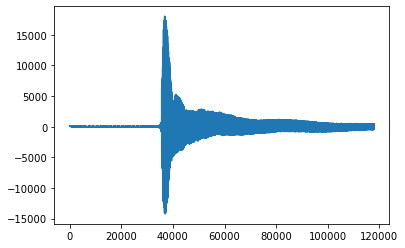

In [6]:
plt.plot(data)

In [151]:
def fir_step(x, a, D, t):
    if t - D < 0:
#         print(f'step at {t}, D {D} with x {x[t]}; a {a} => {x[t]}')
        return x[t]
    else:
#         print(f'step at {t}, D {D} with x {x[t]} and second {x[t-D]}; {a} => {x[t] + a*x[t-D]}')
        return x[t] + a*x[t-D]
    
def FIR(data, a, D):
    data_new = data.copy().astype('float32')
    for i in range(0, data_new.shape[0]):
        data_new[i] = fir_step(data, a, D, i)
    return data_new
    
def get_impulse_response(D, a):
    res = []
    res.append(1.0)
    
    for i in range(1, D):
        res.append(0)
    res.append(a)
    return res

Impulse response [1.0, 0, 0, 0.1]


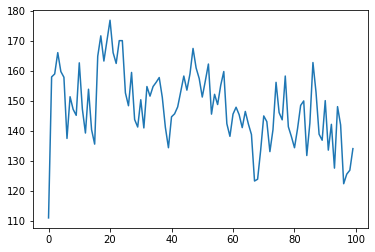

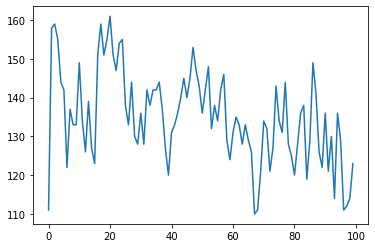

In [154]:
D = 3
a = 0.1


h = get_impulse_response(D, a)

data_new = data.copy()

print('Impulse response', h)

data_new = scipy.signal.lfilter(h, 1, data)
plt.plot(data_new[:100])
plt.show()

plt.plot(data[:100])
plt.show()

Impulse response [1.0, 0, 0, 0.1]


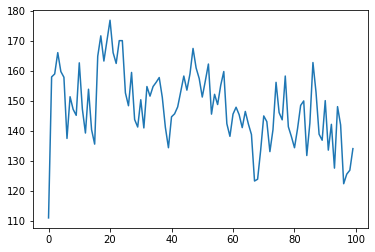

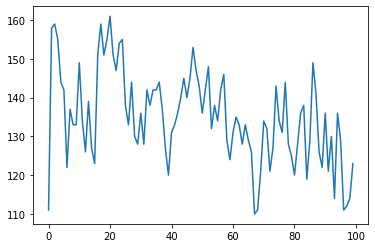

In [155]:

D = 3
a = 0.1

print('Impulse response', get_impulse_response(D, a))

data_new = FIR(data, a, D)

plt.plot(data_new[:100])
plt.show()

plt.plot(data[:100])
plt.show()

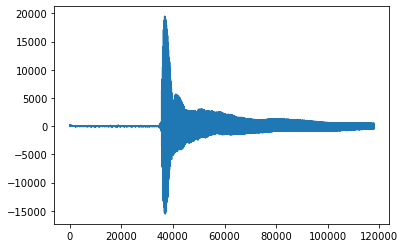

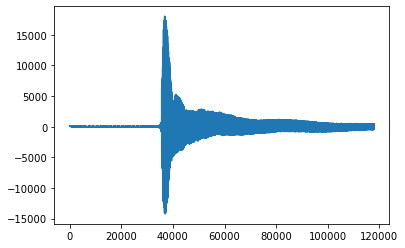

In [171]:
plt.plot(data_new)
plt.show()

plt.plot(data)
plt.show()

In [170]:
sample = data[:10]#np.array([15, 0, 20, 30, 10, 5, 4, 15, 40, 50])
print('sample', sample)

D = 5
a = 0.1

h = get_impulse_response(D, a)
print('Impulse response', h)

sample_scipy = scipy.signal.lfilter(h, 1, sample)
print('scipy', sample_scipy)

sample_cust = FIR(sample, a, D)
print('custom', sample_cust)

sample [111 158 159 155 144 142 122 137 133 133]
Impulse response [1.0, 0, 0, 0, 0, 0.1]
scipy [111.  158.  159.  155.  144.  153.1 137.8 152.9 148.5 147.4]
custom [111.  158.  159.  155.  144.  153.1 137.8 152.9 148.5 147.4]


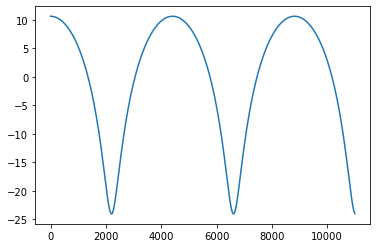

In [169]:
D = 5
a = 0.7


h = get_impulse_response(D, a)

H, W = scipy.signal.freqz(h,fs=samplerate)
plt.plot(H,20*np.log(np.abs(W)+np.finfo(np.float32).eps))

In [105]:
x_fft = fft(data)
x_spectrum_db = 20*np.log(np.abs(x_fft)+np.finfo(np.float32).eps);

s_fft = fft(data_new)
s_spectrum_db = 20*np.log(np.abs(s_fft)+np.finfo(np.float32).eps);

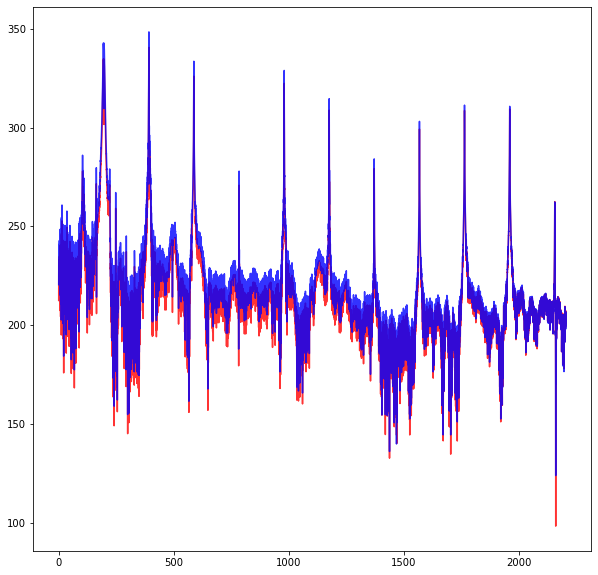

In [106]:
freq_axis = H

T = 1/samplerate

freqs=fftfreq(N, T)

plt.figure(figsize=(10,10))
plt.plot(freqs[:N//10],x_spectrum_db[:N//10], alpha=0.8, c='red')
plt.plot(freqs[:N//10],s_spectrum_db[:N//10], alpha=0.8, c='blue')